# Biodiversity in National Parks
EDA exploring conservation risk across species categories and parks using chi-square analysis and observation data.

## 1. Setup

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Libraries loaded.')

Libraries loaded.


## 2. Load & Clean

In [28]:
species = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')

print(f'species_info : {species.shape}')
print(f'observations : {observations.shape}')

species_info : (5824, 4)
observations : (23296, 3)


In [29]:
# Fill blank conservation_status — no designation means no concern
species['conservation_status'] = species['conservation_status'].fillna('No Concern')

# species_info has 557 rows where the same scientific_name appears multiple times
# with different common name aliases. We keep the most severe conservation status
# per species so no at-risk designation is lost on deduplication.
severity = {
    'No Concern': 0,
    'Species of Concern': 1,
    'In Recovery': 2,
    'Threatened': 3,
    'Endangered': 4
}
species['_sev'] = species['conservation_status'].map(severity)
species = (
    species
    .sort_values('_sev', ascending=False)
    .drop_duplicates(subset='scientific_name', keep='first')
    .drop(columns='_sev')
    .reset_index(drop=True)
)

# Binary at-risk flag: anything with a conservation designation
species['at_risk'] = species['conservation_status'] != 'No Concern'

print(f'species after dedup : {species.shape}')
print(f'\nConservation status breakdown:')
print(species['conservation_status'].value_counts())
print(f'\nAt-risk species: {species["at_risk"].sum()} / {len(species)}')

species after dedup : (5541, 5)

Conservation status breakdown:
conservation_status
No Concern            5362
Species of Concern     151
Endangered              15
Threatened              10
In Recovery              3
Name: count, dtype: int64

At-risk species: 179 / 5541


Three cleaning steps: fill blank status → `"No Concern"`, deduplicate keeping most severe conservation status per species, create binary `at_risk` flag.

In [30]:
# Merge observations with species metadata
merged = observations.merge(
    species[['scientific_name', 'category', 'conservation_status', 'at_risk']],
    on='scientific_name',
    how='left'
)

print(f'Merged shape : {merged.shape}')
print(f'Nulls after join : {merged.isnull().sum().to_dict()}')
merged.head(3)

Merged shape : (23296, 6)
Nulls after join : {'scientific_name': 0, 'park_name': 0, 'observations': 0, 'category': 0, 'conservation_status': 0, 'at_risk': 0}


,scientific_name,park_name,observations,category,conservation_status,at_risk
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,No Concern,False
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,No Concern,False
2,Prunus subcordata,Yosemite National Park,138,Vascular Plant,No Concern,False


Left join on `scientific_name` brings category and conservation info into the observations table. Zero nulls = clean join.

## 3. Conservation Risk by Category
Are certain species categories disproportionately at risk? Chi-square test + Cramér's V effect size.

In [31]:
# Species counts and at-risk rates per category
category_summary = (
    species.groupby('category')
    .agg(
        total=('scientific_name', 'count'),
        at_risk_count=('at_risk', 'sum')
    )
    .assign(at_risk_pct=lambda df: (df['at_risk_count'] / df['total'] * 100).round(1))
    .sort_values('at_risk_pct', ascending=False)
)

print(category_summary)

                   total  at_risk_count  at_risk_pct
category                                            
Mammal               176             30         17.0
Bird                 488             75         15.4
Amphibian             79              7          8.9
Fish                 125             11          8.8
Reptile               78              5          6.4
Nonvascular Plant    333              5          1.5
Vascular Plant      4262             46          1.1


At-risk rate per category. Percentage matters more than raw count — categories vary enormously in size (79 reptiles vs 4,470 plants).

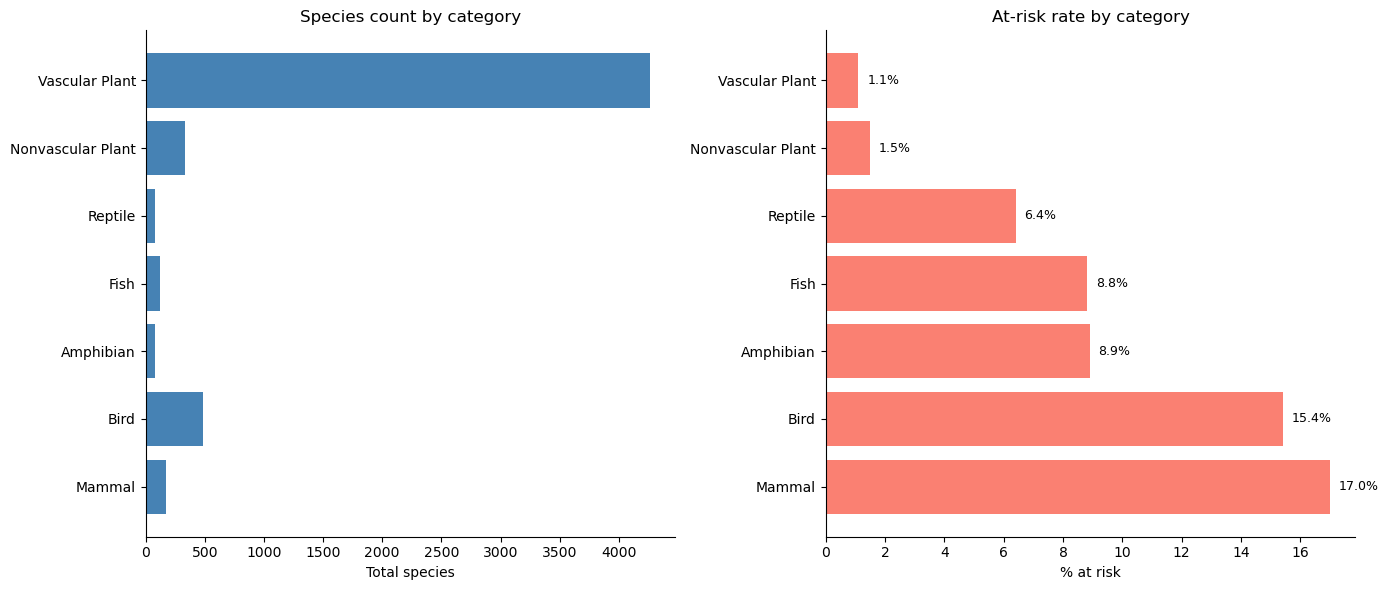

In [32]:
# Visualise at-risk rate per category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: total species by category
axes[0].barh(category_summary.index, category_summary['total'], color='steelblue')
axes[0].set_xlabel('Total species')
axes[0].set_title('Species count by category')

# Right: % at risk by category
bars = axes[1].barh(category_summary.index, category_summary['at_risk_pct'], color='salmon')
axes[1].set_xlabel('% at risk')
axes[1].set_title('At-risk rate by category')
for bar, val in zip(bars, category_summary['at_risk_pct']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Side-by-side: left shows raw species count (context), right shows % at risk (the actual signal). Comparing both prevents size bias misleading the reader.

In [33]:
# Chi-square test of independence: category vs at_risk
contingency = pd.crosstab(species['category'], species['at_risk'])
contingency.columns = ['Not at risk', 'At risk']
print('Contingency table:')
print(contingency)
print()

chi2, p, dof, expected = chi2_contingency(contingency)
cramers_v = association(contingency, method='cramer')

print(f'Chi-square statistic : {chi2:.2f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p:.4f}')
print(f"Cramér's V           : {cramers_v:.4f}")
print()
print('Interpretation:')
if p < 0.05:
    print('  Significant association between species category and at-risk status (p < 0.05).')
else:
    print('  No significant association found (p >= 0.05).')
if cramers_v < 0.1:
    strength = 'negligible'
elif cramers_v < 0.3:
    strength = 'weak'
elif cramers_v < 0.5:
    strength = 'moderate'
else:
    strength = 'strong'
print(f"  Effect size (Cramér's V = {cramers_v:.3f}): {strength}.")

Contingency table:
                   Not at risk  At risk
category                               
Amphibian                   72        7
Bird                       413       75
Fish                       114       11
Mammal                     146       30
Nonvascular Plant          328        5
Reptile                     73        5
Vascular Plant            4216       46

Chi-square statistic : 426.67
Degrees of freedom   : 6
p-value              : 0.0000
Cramér's V           : 0.2775

Interpretation:
  Significant association between species category and at-risk status (p < 0.05).
  Effect size (Cramér's V = 0.277): weak.


**Result:** χ²=426.67, p<0.0001 — conservation risk is not randomly distributed across categories. Cramér's V=0.277 (weak effect): statistically significant but not a dominant relationship. Mammals (17%) and Birds (15.4%) are the most at-risk; Vascular Plants (1.1%) the least, despite being 77% of all species.

## 4. At-Risk Species Distribution Across Parks
Which parks have the highest observation activity for at-risk species? Proportional comparisons only.

In [34]:
# Observation totals split by at-risk status per park
park_summary = (
    merged.groupby(['park_name', 'at_risk'])['observations']
    .sum()
    .unstack()
    .rename(columns={False: 'not_at_risk', True: 'at_risk'})
)
park_summary['total'] = park_summary['not_at_risk'] + park_summary['at_risk']
park_summary['at_risk_pct'] = (park_summary['at_risk'] / park_summary['total'] * 100).round(1)
park_summary = park_summary.sort_values('at_risk_pct', ascending=False)

print(park_summary)

at_risk                              not_at_risk  at_risk    total  \
park_name                                                            
Bryce National Park                       559762    16263   576025   
Yellowstone National Park                1404527    39035  1443562   
Yosemite National Park                    839799    23533   863332   
Great Smoky Mountains National Park       420543    11277   431820   

at_risk                              at_risk_pct  
park_name                                         
Bryce National Park                          2.8  
Yellowstone National Park                    2.7  
Yosemite National Park                       2.7  
Great Smoky Mountains National Park          2.6  


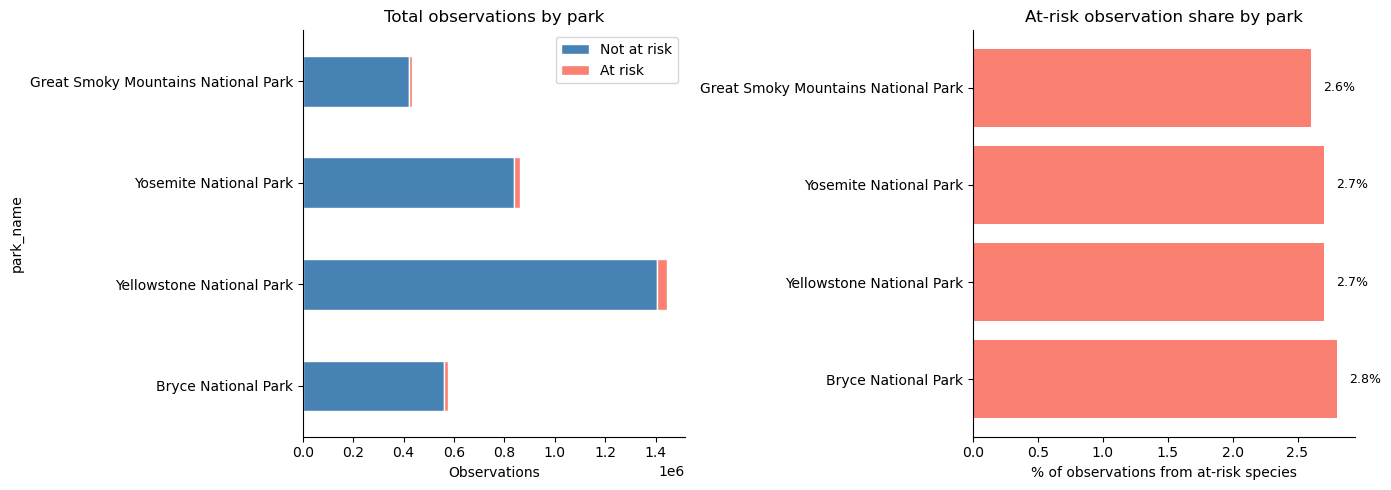

In [35]:
# Stacked bar: observation share by at-risk status per park
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute observation totals
park_summary[['not_at_risk', 'at_risk']].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=['steelblue', 'salmon'], edgecolor='white'
)
axes[0].set_title('Total observations by park')
axes[0].set_xlabel('Observations')
axes[0].legend(['Not at risk', 'At risk'])

# Right: % of observations that are at-risk species
axes[1].barh(park_summary.index, park_summary['at_risk_pct'], color='salmon')
axes[1].set_xlabel('% of observations from at-risk species')
axes[1].set_title('At-risk observation share by park')
for i, val in enumerate(park_summary['at_risk_pct']):
    axes[1].text(val + 0.1, i, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

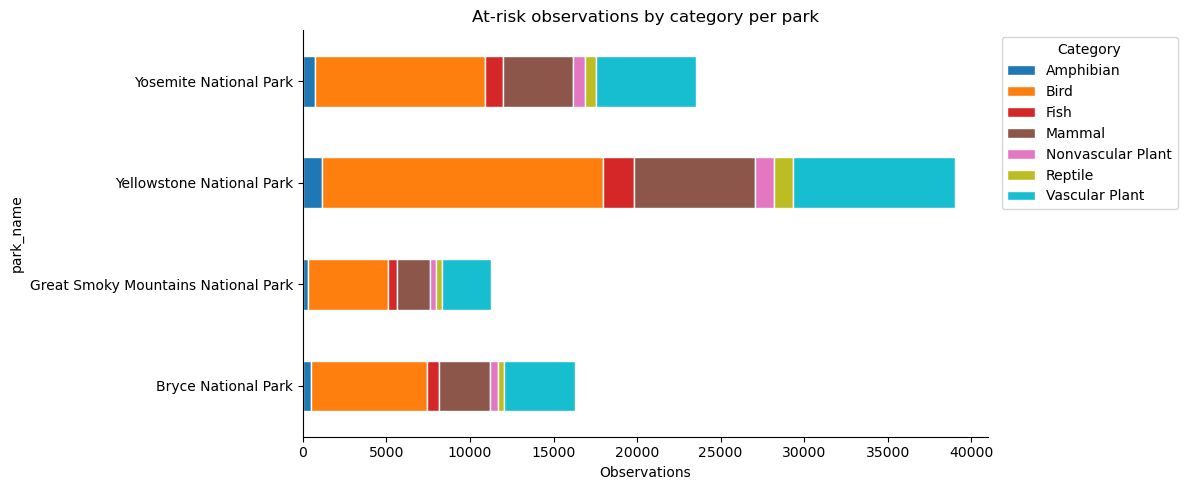

In [36]:
# Category breakdown per park — which categories drive at-risk observations in each park?
park_category = (
    merged[merged['at_risk']]
    .groupby(['park_name', 'category'])['observations']
    .sum()
    .unstack(fill_value=0)
)

park_category.plot(
    kind='barh', stacked=True, figsize=(12, 5),
    colormap='tab10', edgecolor='white'
)
plt.title('At-risk observations by category per park')
plt.xlabel('Observations')
plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Result:** All four parks sit within a narrow band of 2.6–2.8% at-risk observation share. Yellowstone records the most total observations by volume. No single park stands out as a refuge or hotspot — risk is distributed evenly across geography.

## 5. What's Driving the Chi-Square Signal?
Standardised residuals show which category/status combinations are furthest from what we'd expect if risk were distributed randomly.

Standardised residuals (>+2 = over-represented, <-2 = under-represented):
                   Not at risk  At risk
category                               
Amphibian                -0.51     2.78
Bird                     -2.73    14.92
Fish                     -0.63     3.46
Mammal                   -1.86    10.20
Nonvascular Plant         0.32    -1.76
Reptile                  -0.29     1.56
Vascular Plant            1.43    -7.81


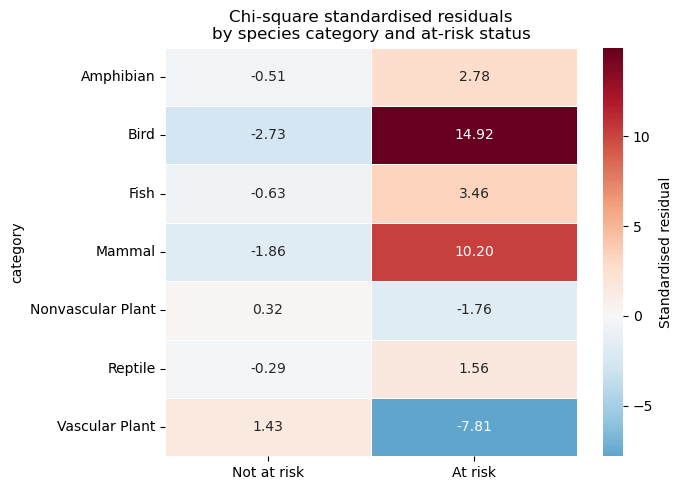

In [37]:
# Standardised residuals: (observed - expected) / sqrt(expected)
# Values > +2 or < -2 are statistically notable
observed = contingency.values
chi2_stat, p_val, dof, expected_vals = chi2_contingency(observed)
std_residuals = (observed - expected_vals) / np.sqrt(expected_vals)

residuals_df = pd.DataFrame(
    std_residuals,
    index=contingency.index,
    columns=['Not at risk', 'At risk']
).round(2)

print("Standardised residuals (>+2 = over-represented, <-2 = under-represented):")
print(residuals_df)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    residuals_df, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Standardised residual'}
)
ax.set_title("Chi-square standardised residuals\nby species category and at-risk status")
plt.tight_layout()
plt.show()

**Result:** Birds (+14.92) and Mammals (+10.20) are the primary drivers of the chi-square signal — far more at-risk than expected. Vascular Plants (-7.81) are strongly under-represented. Reptiles (+1.56) fall below the ±2 threshold — their apparent risk rate is not statistically notable.

## 6. Severity Breakdown by Category
Binary at-risk masks severity. Breaking into Endangered / Threatened / In Recovery / Species of Concern shows whether categories face existential risk or just monitoring flags.

At-risk species count by category and status:
conservation_status  Species of Concern  In Recovery  Threatened  Endangered
category                                                                    
Amphibian                             4            0           2           1
Bird                                 68            3           0           4
Fish                                  4            0           4           3
Mammal                               22            0           2           6
Nonvascular Plant                     5            0           0           0
Reptile                               5            0           0           0
Vascular Plant                       43            0           2           1


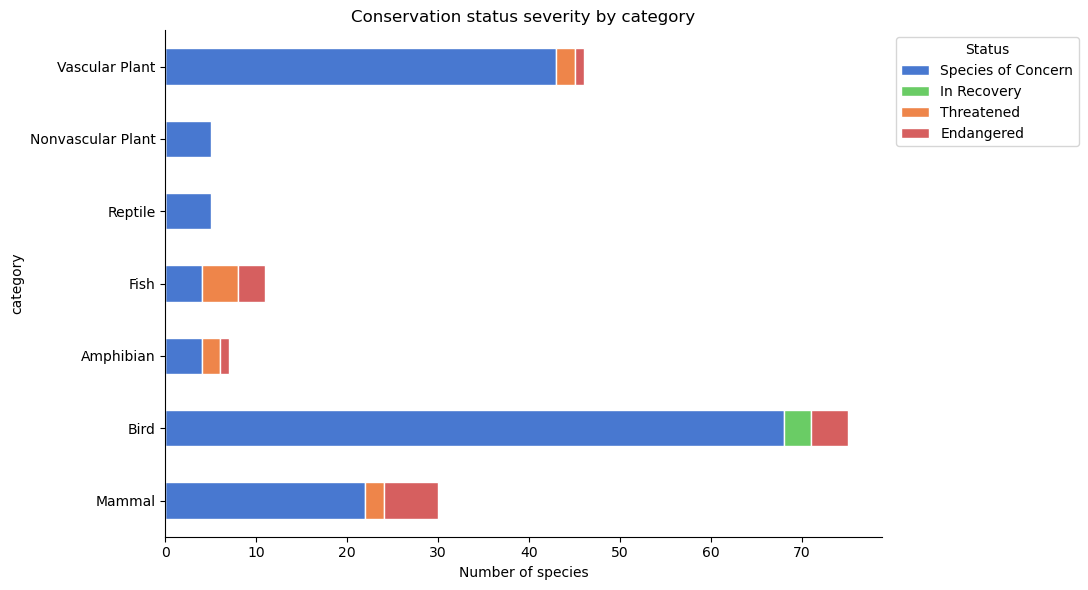

In [38]:
# Conservation status severity breakdown per category (at-risk only)
status_order = ['Species of Concern', 'In Recovery', 'Threatened', 'Endangered']
at_risk_species = species[species['at_risk']].copy()

severity_breakdown = (
    at_risk_species.groupby(['category', 'conservation_status'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[s for s in status_order if s in at_risk_species['conservation_status'].unique()])
)

print("At-risk species count by category and status:")
print(severity_breakdown)

# Stacked bar — ordered by total at-risk count
severity_breakdown.loc[category_summary.index].plot(
    kind='barh', stacked=True, figsize=(11, 6),
    color=['#4878d0', '#6acc65', '#ee854a', '#d65f5f'],
    edgecolor='white'
)
plt.title('Conservation status severity by category')
plt.xlabel('Number of species')
plt.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Result:** Birds have breadth (68 Species of Concern) but only 4 Endangered. Mammals have depth — 6 Endangered, the highest of any category. Fish show the most severe profile proportionally: 7 of 11 at-risk fish are Threatened or Endangered (64%).

## 7. The 15 Endangered Species
Only 15 species hold Endangered status. Identifying them and where they're observed most tells the most urgent conservation story in the data.

In [39]:
# The 15 endangered species
endangered = species[species['conservation_status'] == 'Endangered'][
    ['category', 'scientific_name', 'common_names']
].sort_values('category')

print(f"Endangered species ({len(endangered)} total):")
print(endangered.to_string(index=False))

Endangered species (15 total):
      category              scientific_name                                                common_names
     Amphibian                 Rana sierrae                            Sierra Nevada Yellow-Legged Frog
          Bird            Picoides borealis                                     Red-Cockaded Woodpecker
          Bird          Vermivora bachmanii                   Bachman's Warbler, Bachman's Wood Warbler
          Bird               Grus americana                                              Whooping Crane
          Bird      Gymnogyps californianus                                           California Condor
          Fish              Noturus baileyi                                                Smoky Madtom
          Fish         Etheostoma percnurum                                            Duskytail Darter
          Fish            Chasmistes liorus                                                 June Sucker
        Mammal               Myot

Total endangered species observations per park:
park_name
Yellowstone National Park              1228
Yosemite National Park                  747
Bryce National Park                     489
Great Smoky Mountains National Park     334
dtype: int64



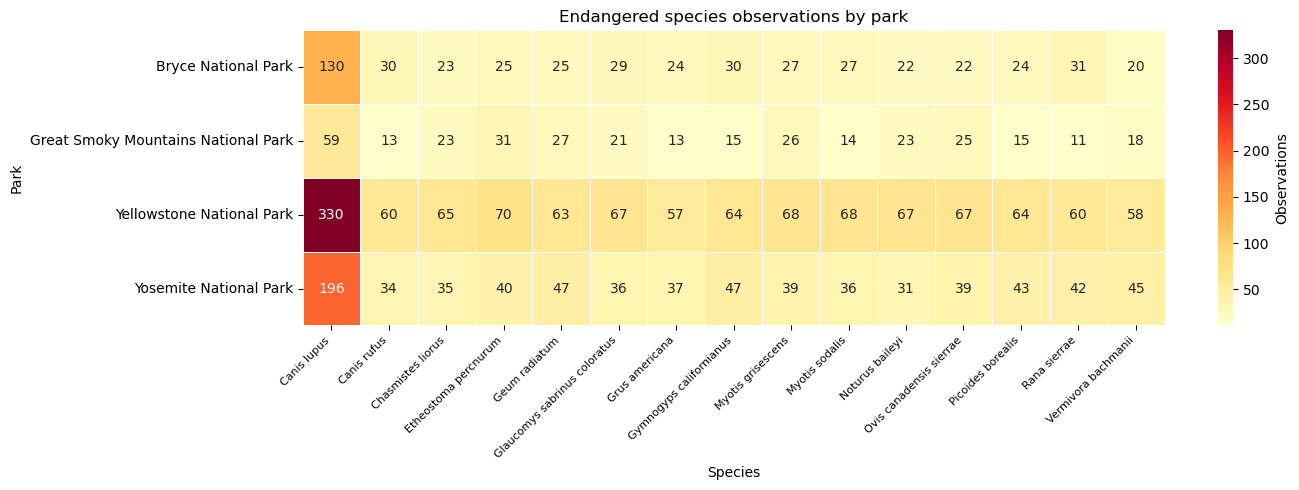

In [40]:
# Observations of endangered species per park
endangered_obs = (
    merged[merged['conservation_status'] == 'Endangered']
    .groupby(['park_name', 'scientific_name'])['observations']
    .sum()
    .unstack(fill_value=0)
)

# Total endangered observations per park
endangered_totals = endangered_obs.sum(axis=1).sort_values(ascending=False)
print("Total endangered species observations per park:")
print(endangered_totals)
print()

# Heatmap: which endangered species are seen where
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    endangered_obs, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'Observations'}
)
ax.set_title('Endangered species observations by park')
ax.set_xlabel('Species')
ax.set_ylabel('Park')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

**Result:** Yellowstone records the most endangered species observations (1,228) — nearly 4× Great Smoky Mountains (334). Includes Gray Wolf, Red Wolf, and Indiana Bat. The heatmap shows which specific species are observed in which parks.

## 8. Category Risk per Park
Parks looked identical at ~2.7% overall. Does that hold within each category, or does park composition vary?

At-risk observation % by category and park:
park_name          Bryce National Park  Great Smoky Mountains National Park  \
category                                                                      
Amphibian                          6.7                                  5.8   
Bird                              13.4                                 12.6   
Fish                               5.9                                  5.9   
Mammal                            14.8                                 13.1   
Nonvascular Plant                  1.5                                  1.5   
Reptile                            4.9                                  6.4   
Vascular Plant                     0.9                                  0.9   

park_name          Yellowstone National Park  Yosemite National Park  
category                                                              
Amphibian                                6.0                     6.6  
Bird                           

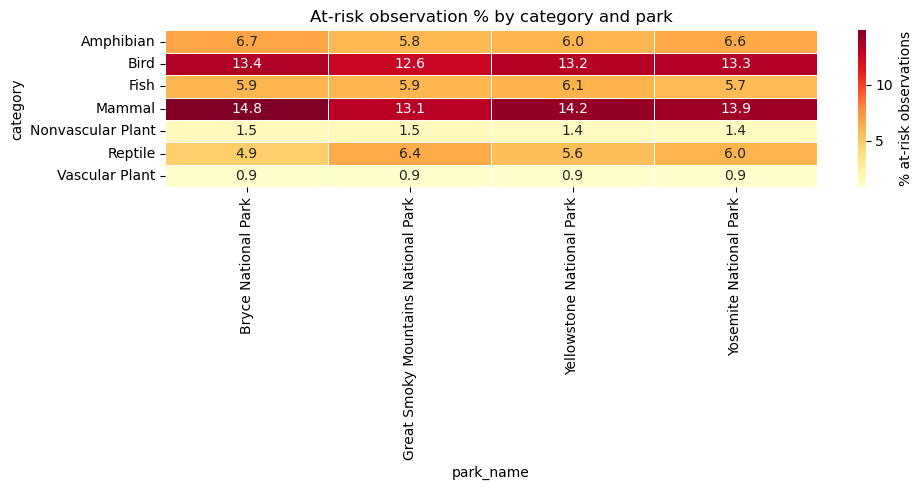

In [41]:
# At-risk observation % broken down by category × park
cat_park = (
    merged.groupby(['park_name', 'category', 'at_risk'])['observations']
    .sum()
    .unstack('at_risk')
    .rename(columns={False: 'not_at_risk', True: 'at_risk'})
    .fillna(0)
)
cat_park['at_risk_pct'] = (
    cat_park['at_risk'] / (cat_park['at_risk'] + cat_park['not_at_risk']) * 100
).round(1)

# Pivot: rows = category, columns = park
cat_park_pivot = cat_park['at_risk_pct'].unstack('park_name')
print("At-risk observation % by category and park:")
print(cat_park_pivot.round(1))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    cat_park_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': '% at-risk observations'}
)
ax.set_title('At-risk observation % by category and park')
plt.tight_layout()
plt.show()

**Result:** At-risk rates are near-identical across all four parks within every category — Mammals ~14%, Birds ~13%, Fish ~6%, Plants ~1% regardless of park. Conservation risk is systemic at the species level, not driven by geography.

## 9. Conclusions

Conservation risk across US national parks is non-random and concentrated in vertebrate groups, but the story differs by category:

- **Mammals and Birds** are disproportionately at risk (17% and 15.4% respectively), confirmed by chi-square (χ²=426.67, p<0.0001). Birds drive the signal through volume — 75 at-risk species — but Mammals carry the most severe risk with 6 Endangered species including Gray Wolf, Red Wolf, and Indiana Bat.
- **Fish are an overlooked concern**: only 11 at-risk fish species, but 64% of them hold Threatened or Endangered status — the highest severity concentration of any category.
- **Vascular Plants** appear safer (1.1% at-risk) but this likely reflects under-monitoring, not true safety. The residual of -7.81 suggests plants are systematically under-represented in conservation listings relative to their proportion of species.
- **Parks are not differentiating factors**: all four parks show near-identical at-risk profiles (2.6–2.8% overall, ~14% for Mammals in every park). Risk is systemic across species, not concentrated in particular locations.
- **Yellowstone** records the most endangered species observations by volume (1,228), driven partly by its wolf and bat populations.

**Limitation:** Observation counts reflect recorded activity, not confirmed population size. Survey effort across parks and time periods is unknown, which limits causal inference from the observations data.